In [ ]:
# Retail Sales Analysis — Online Retail II Dataset

## Project Overview
This project analyses transactional sales data from a UK-based online retailer covering the period December 2009 to December 2011. The dataset contains over 1 million transactions across 43 countries.

The goal of this analysis is to uncover actionable business insights across four key areas:
- **Product Performance** — what sells and what doesn't
- **Seasonal Trends** — when does the business peak and decline
- **Customer Markets** — where is revenue coming from
- **Operational Patterns** — when do customers order

## Dataset
- **Source:** UCI Machine Learning Repository via Kaggle
- **Dataset:** Online Retail II
- **Period:** December 2009 — December 2011
- **Final Clean Dataset:** 1,028,761 transactions across 8 columns

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Key Questions Explored
1. Which products drive the most revenue and volume?
2. What seasonal patterns exist in the data?
3. Which international markets represent the biggest opportunity?
4. When do customers order — by month, day and hour?
5. What does the cancellation data reveal about product quality?
6. Which products should be considered for discontinuation?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('online_retail_II.csv')
print(df.head())
print(df.shape)
print(df.columns)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
(1067371, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [4]:
# Check for missing values
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [5]:
# Check data types
print(df.dtypes)

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In [6]:
# Basic statistics
print(df.describe())

           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


In [7]:
df= df.dropna(subset=['Description'])
print(df.isnull().sum())

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    238625
Country             0
dtype: int64


In [8]:
df[df['Quantity']>0 ]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
# Create Revenue column
df['Revenue'] = df['Quantity']* df['Price']
print (df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  Revenue  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom    100.8  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom     30.0  


In [10]:
# Check for fully duplicated rows
print(df.duplicated().sum())

34228


In [11]:
#remove duplicated rows
df = df.drop_duplicates()
print(df.shape)

(1028761, 9)


In [ ]:
## Data Cleaning Summary
- Started with 1,067,371 rows and 8 columns
- Dropped 4,382 rows with missing Description values
- Retained rows with missing Customer ID (not relevant for product analysis)
- Confirmed no negative or zero Quantity values
- Dropped 34,228 fully duplicated rows
- Created a new `Revenue` column (Quantity × Price)
- Final clean dataset: 1028761 rows

In [40]:
## Sales Analysis

In [12]:
revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending= False).round(2)
print(revenue_by_country.head(10))

Country
United Kingdom    15986060.34
EIRE                609953.78
Netherlands         548330.70
Germany             411959.16
France              321733.39
Australia           166444.42
Switzerland          99403.06
Spain                91013.44
Sweden               87775.52
Denmark              64459.59
Name: Revenue, dtype: float64


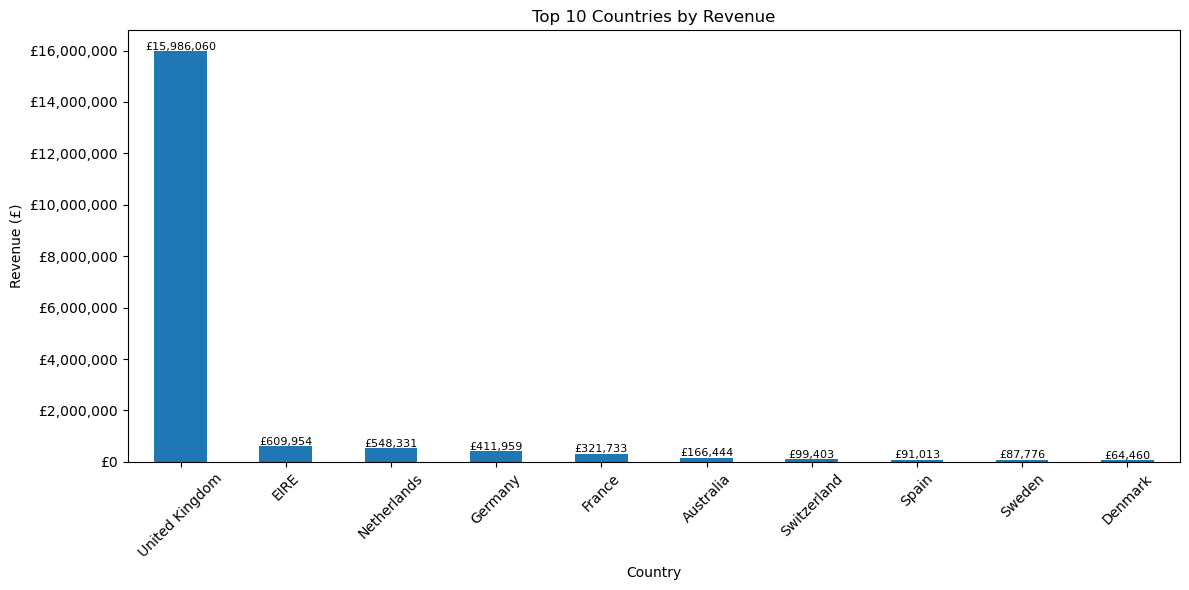

In [13]:
#Revenue Chart Display
revenue_by_country.head(10).plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

for i, v in enumerate(revenue_by_country.head(10)):
    plt.text(i, v + 50000, f'£{v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
##Revenue by Month

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month and year into a new column
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# Group by MonthYear and sum Revenue
revenue_by_month = df.groupby('MonthYear')['Revenue'].sum().round(2)

print(revenue_by_month)

MonthYear
2009-12     796648.50
2010-01     622479.50
2010-02     531265.37
2010-03     763247.24
2010-04     587926.69
2010-05     613270.72
2010-06     677073.87
2010-07     573333.69
2010-08     654774.39
2010-09     851105.96
2010-10    1041685.61
2010-11    1416697.20
2010-12     746723.61
2011-01     558448.56
2011-02     497026.41
2011-03     682013.98
2011-04     492367.84
2011-05     722094.10
2011-06     689977.23
2011-07     680156.99
2011-08     681386.46
2011-09    1017596.68
2011-10    1069368.23
2011-11    1456145.80
2011-12     432719.06
Freq: M, Name: Revenue, dtype: float64


In [ ]:
## Revenue by Month - Key Observations
- Clear seasonal pattern visible across both years
- Revenue peaks in November each year, likely driven by Black Friday and early Christmas gift purchasing
- Sharp December decline suggests customers have concerns about delivery lead times ahead of Christmas
- Post-Christmas dip in January is expected as consumer spending recovers
- Overall revenue trend appears consistent year on year

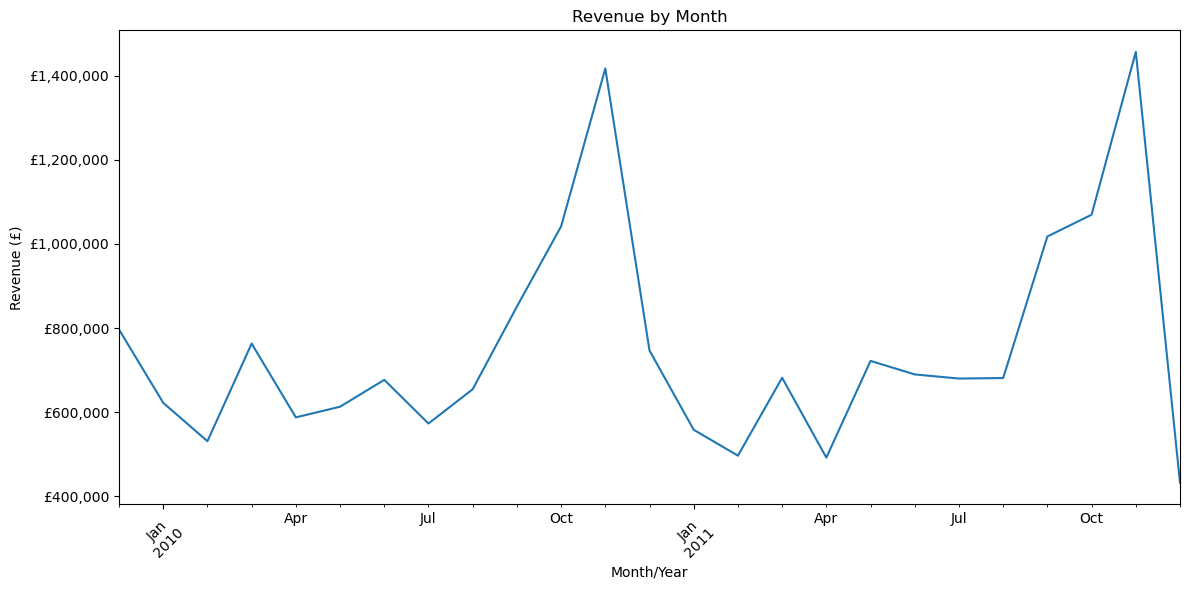

In [61]:
#populate the chart

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

revenue_by_month.plot(kind='line', figsize=(12,6))
plt.title('Revenue by Month')
plt.xlabel('Month/Year')
plt.ylabel('Revenue (£)')
plt.xticks(rotation = 45)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))
plt.tight_layout()
plt.show();

In [15]:
## Top 10 Products by Revenue

top_10 = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).round(2)
print(top_10.head(10))

Description
REGENCY CAKESTAND 3 TIER               314045.02
DOTCOM POSTAGE                         309844.10
WHITE HANGING HEART T-LIGHT HOLDER     251603.12
PARTY BUNTING                          147079.73
JUMBO BAG RED RETROSPOT                145946.05
ASSORTED COLOUR BIRD ORNAMENT          128550.42
PAPER CHAIN KIT 50'S CHRISTMAS         116298.59
POSTAGE                                110430.41
CHILLI LIGHTS                           79905.13
ROTATING SILVER ANGELS T-LIGHT HLDR     70969.95
Name: Revenue, dtype: float64


In [16]:
## Top 10 Products by Revenue cleaned(without postage)

# Remove postage entries
top_10 = top_10[~top_10.index.str.contains('POSTAGE', case= False)]
top_10.head(10)

Description
REGENCY CAKESTAND 3 TIER               314045.02
WHITE HANGING HEART T-LIGHT HOLDER     251603.12
PARTY BUNTING                          147079.73
JUMBO BAG RED RETROSPOT                145946.05
ASSORTED COLOUR BIRD ORNAMENT          128550.42
PAPER CHAIN KIT 50'S CHRISTMAS         116298.59
CHILLI LIGHTS                           79905.13
ROTATING SILVER ANGELS T-LIGHT HLDR     70969.95
JUMBO BAG STRAWBERRY                    68489.89
RABBIT NIGHT LIGHT                      66661.63
Name: Revenue, dtype: float64

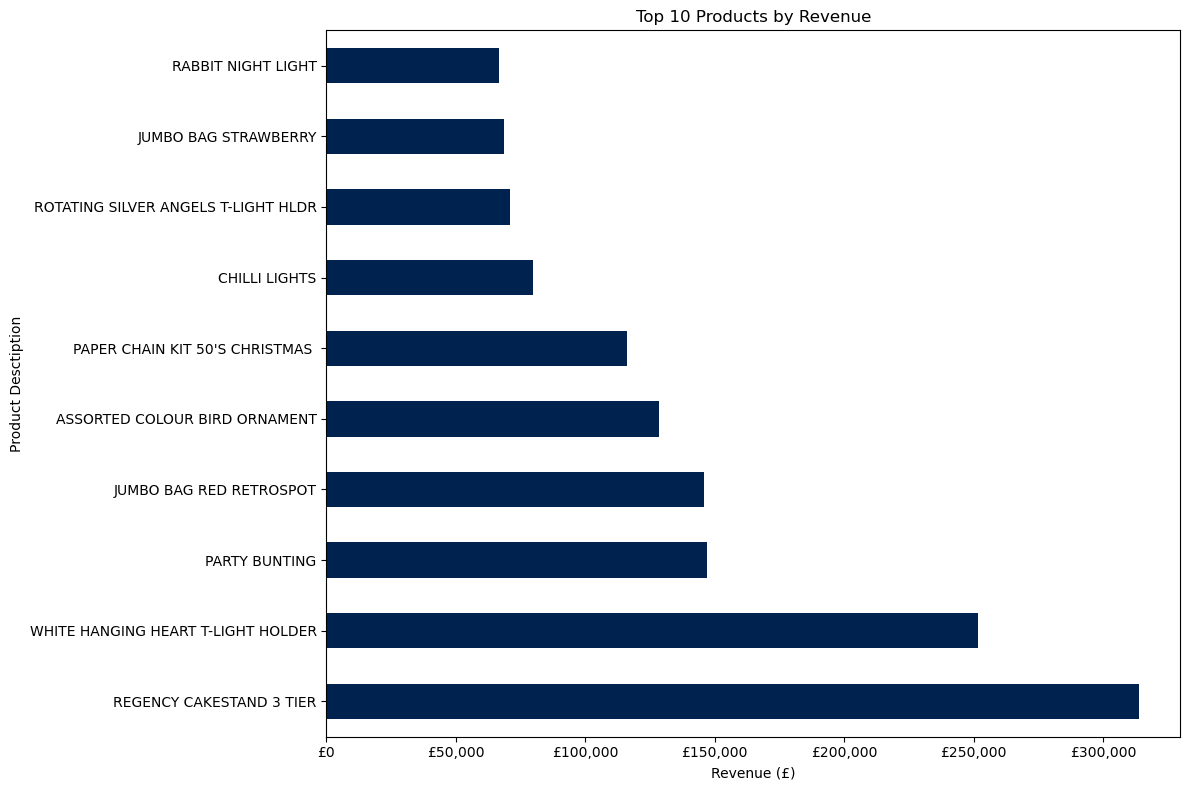

In [18]:
#Visualizing data with a chart

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

top_10.head(10).plot(kind='barh', figsize=(12,8),colormap='cividis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product Desctiption')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show();

In [20]:
# Revenue By Day of Week

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

## Group by DayOfWeek and sum Revenue
revenue_by_day = df.groupby('DayOfWeek')['Revenue'].sum().round(2)

##Sort days of the week in logical order:
day_order =  ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

revenue_by_day = revenue_by_day.reindex(day_order)
revenue_by_day

DayOfWeek
Monday       3273178.57
Tuesday      3724295.59
Wednesday    3278445.13
Thursday     3886516.90
Friday       2904261.24
Saturday        9803.05
Sunday       1779033.21
Name: Revenue, dtype: float64

In [ ]:
#Key Observations Revenue by Day of Week 
-highest sales days are Tuesdays and Thursdays and it tapers down as we approach the weekend.   
-almost no sales on a Saturday which can be due to the fact that most of the companies customers are wholesales whos busiest days are probably saturdays where they need to attend to their customers and not placing orders 
-slight uptake on Sundays as the wholesalers prepare for the week ahead and order stock for the next cycle.

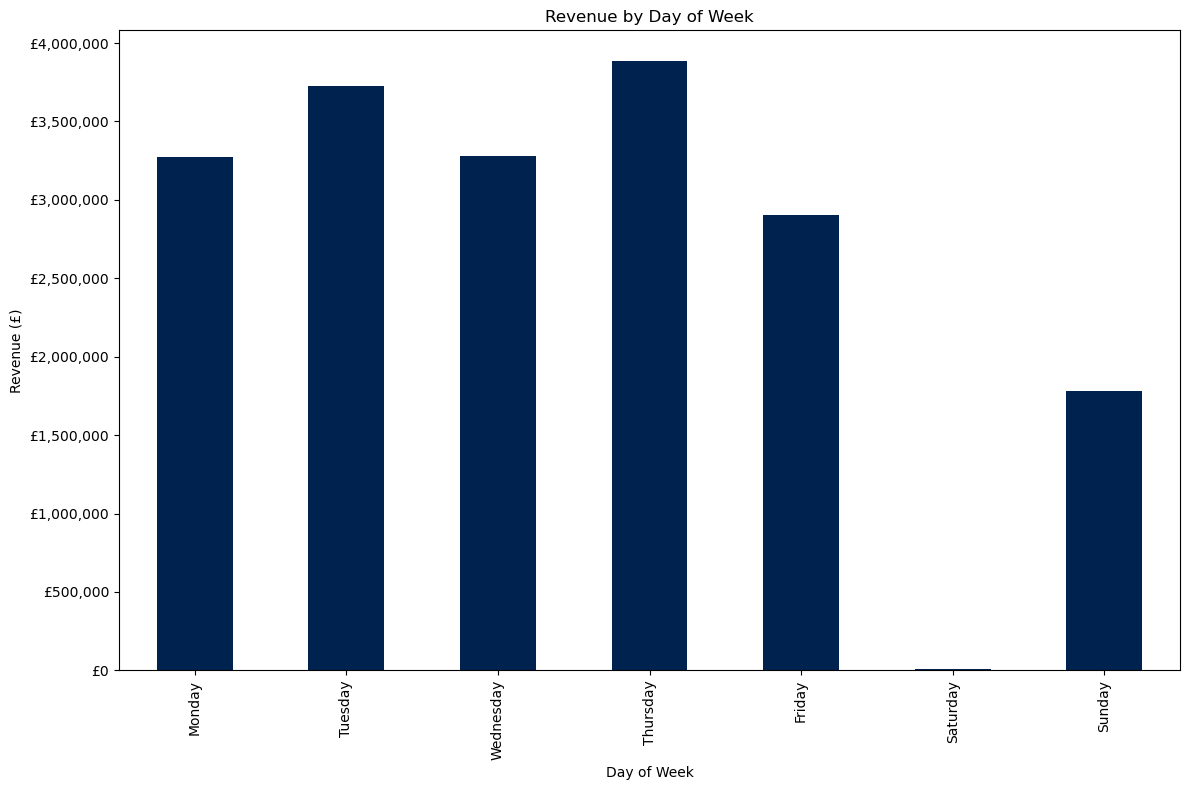

In [21]:
## Plot Revenue by day on a chart.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

revenue_by_day.plot(kind='bar', figsize=(12,8),colormap='cividis')
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show();

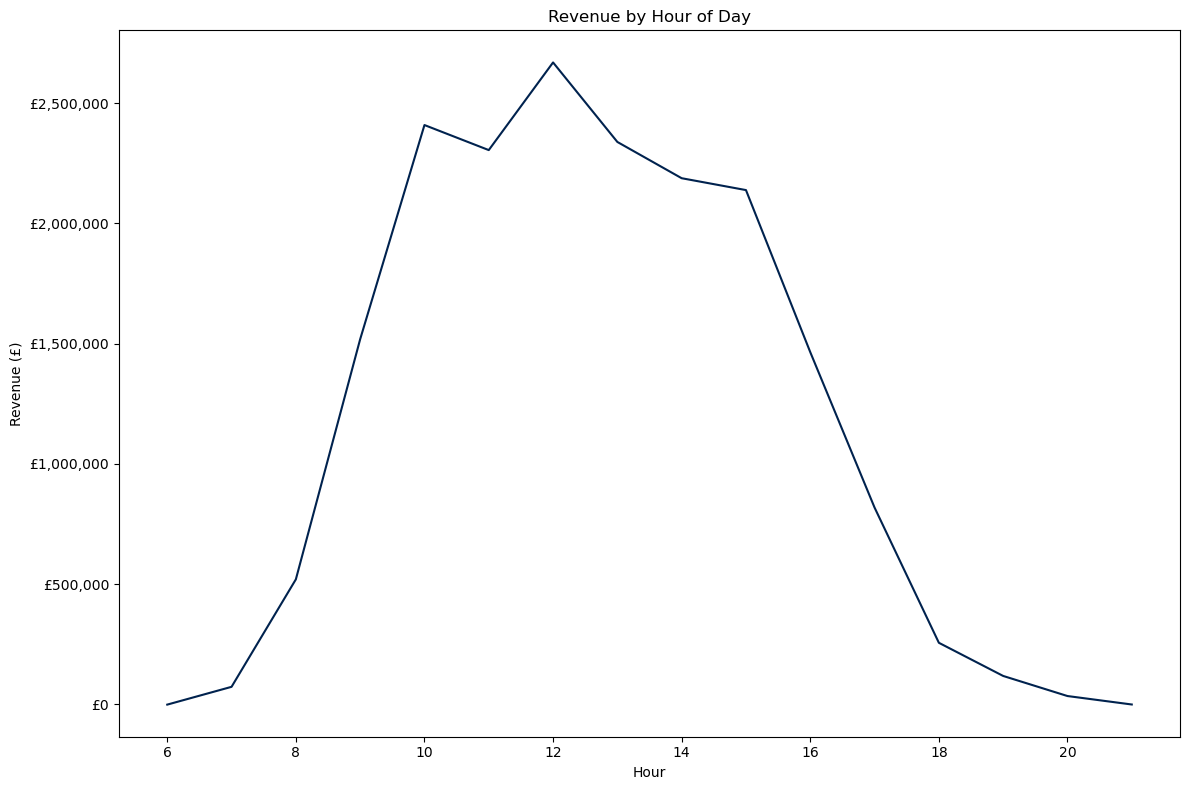

In [22]:
#Revenue by Hour of Day

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df['Hour'] = df['InvoiceDate'].dt.hour
revenue_by_hour = df.groupby('Hour')['Revenue'].sum().round(2)

#Visualization - Chart
revenue_by_hour.plot(kind='line', figsize=(12,8),colormap='cividis')

plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show();

In [ ]:
## Revenue by Hour of Day - Key Observations
- Revenue peaks at 12:00pm suggesting customers place orders during lunch breaks
- Core trading window is 10:00 - 16:00, generating the majority of daily revenue
- No overnight activity confirms this is a **B2B/wholesale operation**, not a 24/7 consumer retailer
- Sharp drop after 18:00 suggests an informal order cut-off time
- This pattern is consistent with the day of week analysis — both confirm a wholesale customer base operating strictly within business hours

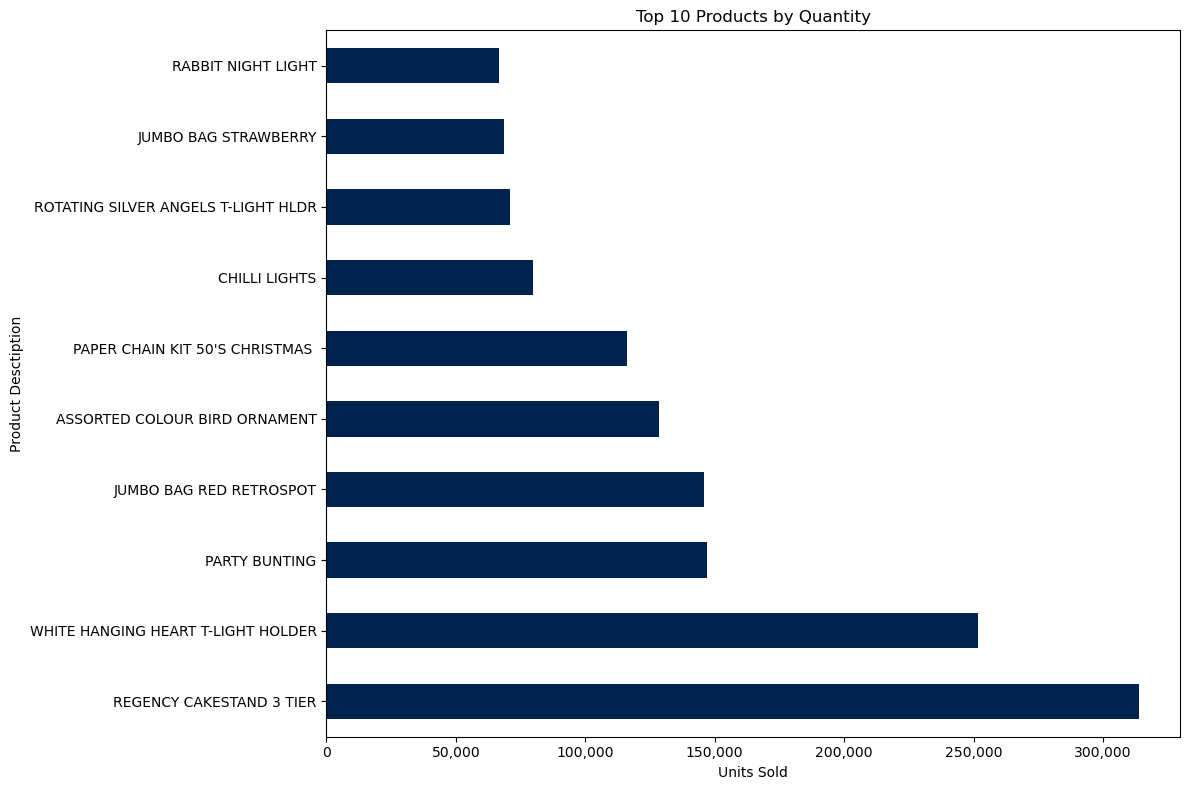

In [24]:
# Top 10 Products by Quantity Sold

Top_10_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending = False)

top_10_quantity = top_10[~top_10.index.str.contains('POSTAGE', case= False)]
top_10_quantity.head(10)

#Visualization- Chart

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

top_10_quantity.head(10).plot(kind='barh', figsize=(12,8),colormap='cividis')
plt.title('Top 10 Products by Quantity')
plt.xlabel('Units Sold')

plt.ylabel('Product Desctiption')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show();


In [ ]:
## Top 10 Products by Quantity - Key Observations
- The top 10 products by quantity sold are identical to the top 10 by revenue, suggesting these are the core products driving the business
- REGENCY CAKESTAND 3 TIER leads in both revenue and units sold by a significant margin
- This consistency indicates pricing is relatively uniform across top products — no single product is inflating revenue through high price alone
- These products should be prioritised for stock management, promotions and supplier negotiations

In [25]:
#Cancellation Analysis
cancellations = df[df['Invoice'].astype(str).str.startswith('C')]
print(cancellations.shape)
print(cancellations.head())

(19104, 12)
     Invoice StockCode                    Description  Quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896             POTTING SHED TWINE        -6   
182  C489449     22083     PAPER CHAIN KIT RETRO SPOT       -12   

            InvoiceDate  Price  Customer ID    Country  Revenue MonthYear  \
178 2009-12-01 10:33:00   2.95      16321.0  Australia    -35.4   2009-12   
179 2009-12-01 10:33:00   1.65      16321.0  Australia     -9.9   2009-12   
180 2009-12-01 10:33:00   4.25      16321.0  Australia    -17.0   2009-12   
181 2009-12-01 10:33:00   2.10      16321.0  Australia    -12.6   2009-12   
182 2009-12-01 10:33:00   2.95      16321.0  Australia    -35.4   2009-12   

    DayOfWeek  Hour  
178   Tuesday    10  
179   Tuesday    10  
180   Tuesday    10  
181   Tuesday    10  
182   Tuesda

In [26]:
## Top 10 most cancelled products
top_cancellations = cancellations.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False)
top_cancellations = top_cancellations[~top_cancellations.index.str.contains('POSTAGE', case=False)]
top_cancellations = top_cancellations.head(10)
print(top_cancellations)

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9381
SET/6 FRUIT SALAD PAPER CUPS            7140
SET/6 FRUIT SALAD  PAPER PLATES         7008
Manual                                  5443
POP ART PEN CASE & PENS                 5184
BLACK SILVER FLOWER T-LIGHT HOLDER      5040
MULTICOLOUR SPRING FLOWER MUG           4996
TEATIME PEN CASE & PENS                 4632
Name: Quantity, dtype: int64


In [ ]:
## Top 10 Cancellations - Key Observations
- Total cancellations of 19,104 orders appears manageable at first glance,however the quantities cancelled tell a different story.
- **PAPER CRAFT, LITTLE BIRDIE (80,995 units)** and **MEDIUM CERAMIC TOP STORAGE JAR (74,494 units)** are outliers — nearly 8x higher than the third highest cancellation.
- These two products require urgent investigation — possible causes include quality issues, supplier problems, a product recall or a bulk order cancellation.
- **"Manual"** appearing in the list suggests system adjustment entries are being recorded as cancellations — this should be reviewed with the business
- The remaining 8 products show relatively low cancellation volumes and are likely normal operational cancellations.
- Recommendation: Flag PAPER CRAFT, LITTLE BIRDIE and MEDIUM CERAMIC TOP STORAGE JAR for immediate review with the procurement and quality teams.

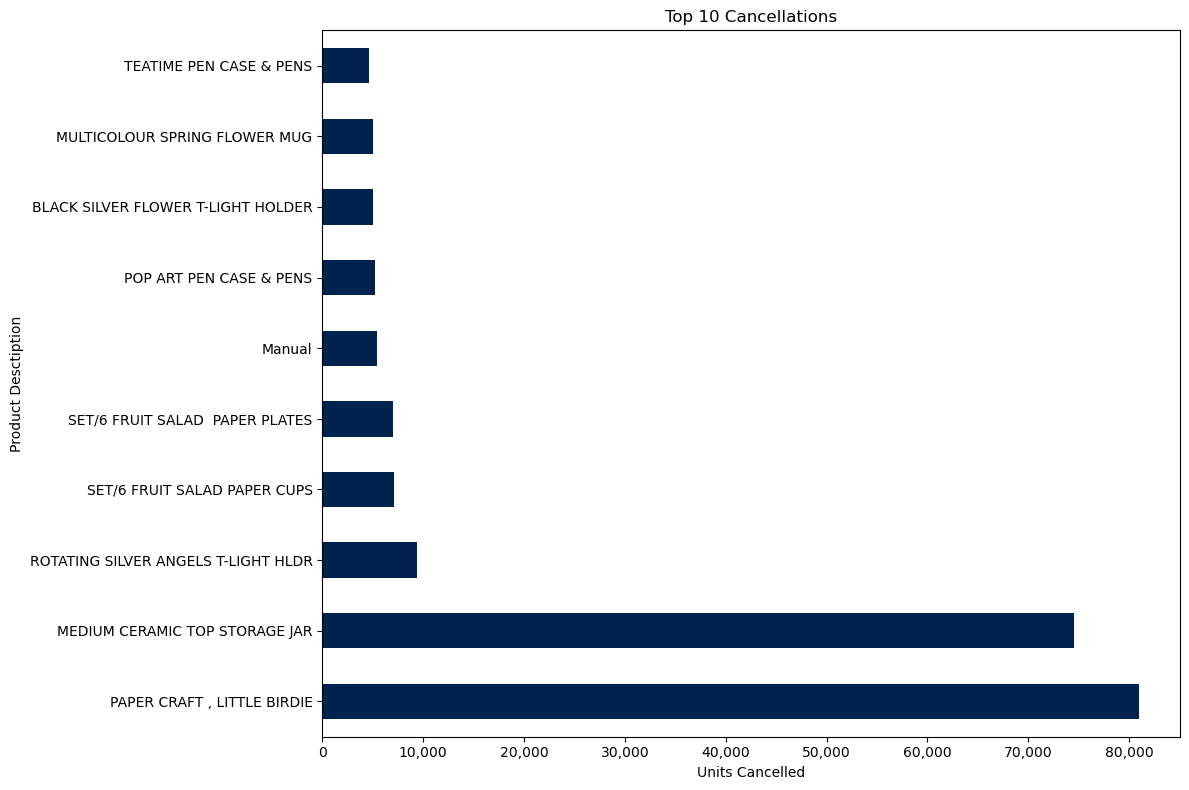

In [27]:
#Visualization - Chart
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

top_cancellations.head(10).plot(kind='barh', figsize = (12,8), colormap= 'cividis')
plt.title('Top 10 Cancellations')
plt.xlabel('Units Cancelled')
plt.ylabel('Product Desctiption')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show();

In [28]:
#Average Order Value

## Calculate total value per invoice
order_values = df.groupby('Invoice')['Revenue'].sum()
aov = order_values.mean().round(2)

print(f'Average Order Value: £{aov:,.2f}')

Average Order Value: £382.05


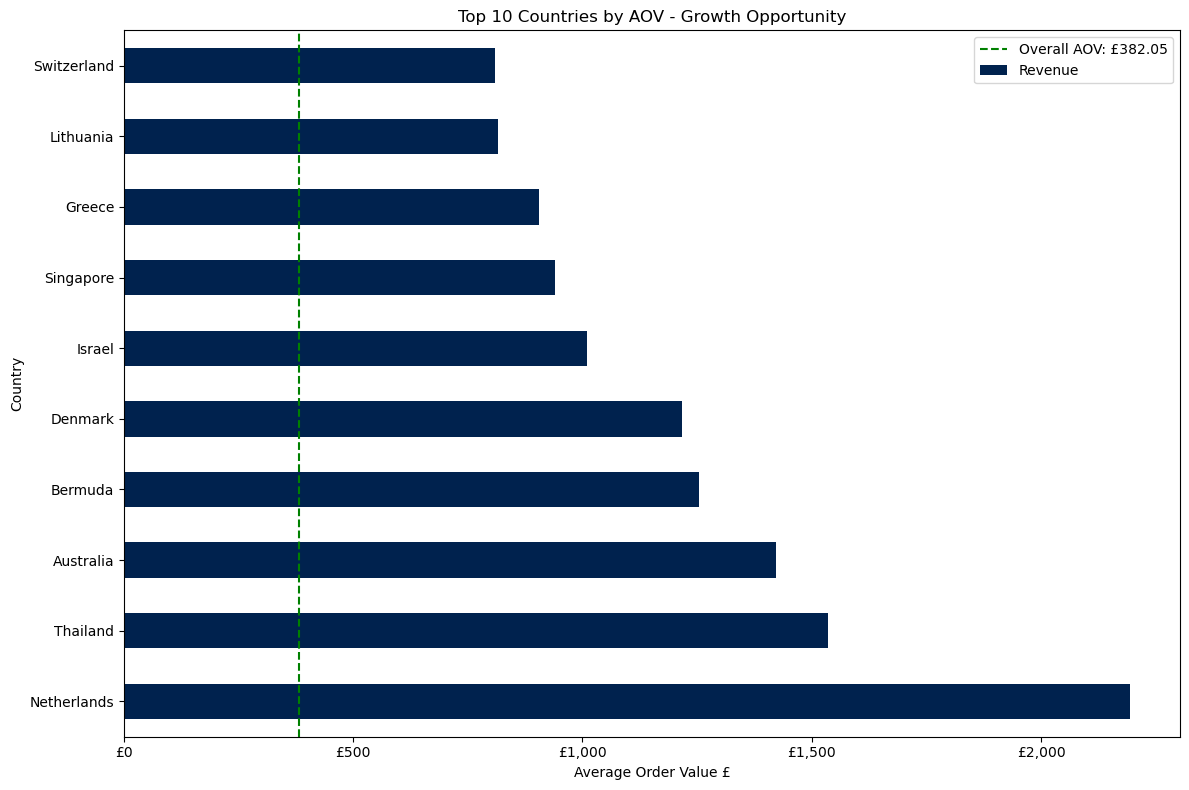

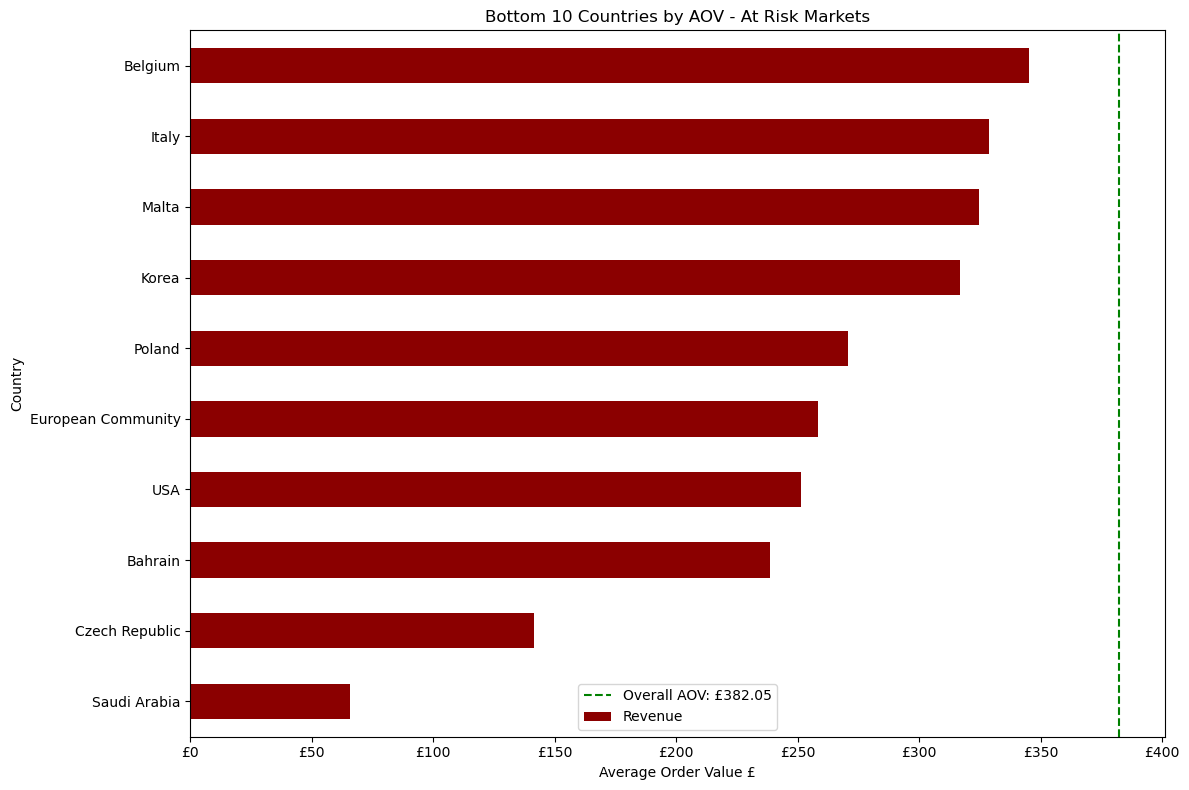

In [43]:
# Average Order Value by Country
# Best 10 Countries by AOV
aov_by_country_full = df.groupby(['Country', 'Invoice'])['Revenue'].sum().reset_index()
aov_by_country_full = aov_by_country_full.groupby('Country')['Revenue'].mean().round(2)

# Top 10
aov_top10 = aov_by_country_full.sort_values(ascending=False).head(10)

# Bottom 10 - excluding negative values 
aov_bottom10 = aov_by_country_full[aov_by_country_full > 0].sort_values(ascending=True).head(10)

#Top 10 Chart
aov_top10.plot(kind='barh', figsize=(12,8), colormap='cividis')
plt.title('Top 10 Countries by AOV - Growth Opportunity')
plt.xlabel('Average Order Value £')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.axvline(x=aov, color='green', linestyle='--', linewidth=1.5, label=f'Overall AOV: £{aov:,.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Bottom 10 Chart
aov_bottom10.plot(kind='barh', figsize=(12,8), color='#8b0000')
plt.title('Bottom 10 Countries by AOV - At Risk Markets')
plt.xlabel('Average Order Value £')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.axvline(x=aov, color='green', linestyle='--', linewidth=1.5, label=f'Overall AOV: £{aov:,.2f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Average Order Value by Country - Key Observations
- Overall Average Order Value across all markets is **£382.05**
- **Netherlands leads** with the highest AOV, significantly above all other markets
- **Australia and Thailand** show high AOV despite not being top revenue markets — they place fewer but larger orders, representing strong growth opportunity
- **United Kingdom at £356** sits below the overall average despite dominating total revenue — high volume but smaller individual orders consistent with a wholesale customer base
- **Bottom 10 markets** represent either underdeveloped markets with growth  potential or at-risk markets where customer relationships need attention
- **Nigeria showed a negative AOV** — flagged as a data quality issue requiring investigation

### Strategic Recommendation
High AOV markets like Netherlands, Australia and Thailand should be prioritised for targeted sales and marketing efforts as they demonstrate the highest revenue potential per order.

In [29]:
 #Month over Month Growth Rate

mom_growth = revenue_by_month.pct_change()*100
mom_growth = mom_growth.round(2)

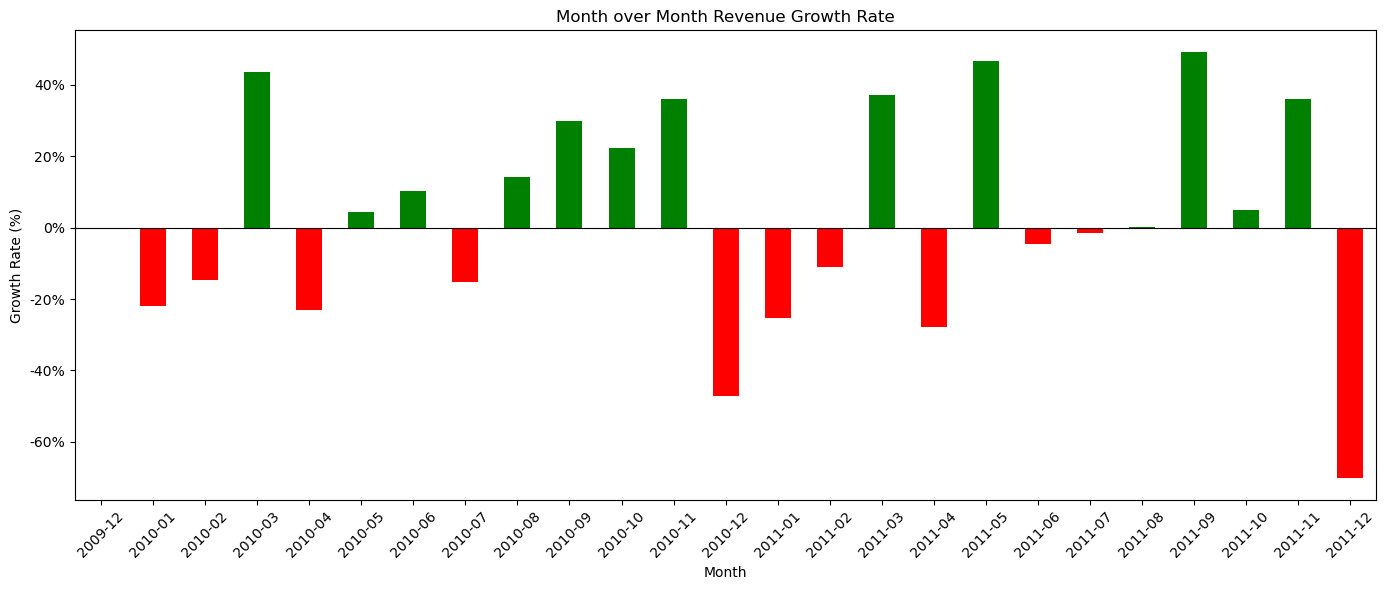

In [30]:
#Visualition

colors = ['green' if x > 0 else 'red' for x in mom_growth]

mom_growth.plot(kind='bar', figsize=(14,6), color=colors)
plt.title('Month over Month Revenue Growth Rate')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Month over Month Growth Rate - Key Observations
- Overall month on month growth is mostly positive indicating a healthy and growing business over the period
- Strong growth momentum builds from **September through to November** with each month growing steadily, peaking in November ahead of the festive season
- **March shows consistent growth** in both years — possibly driven by seasonal demand or wholesale clients stocking up before financial year end
- **December shows a worsening decline year on year** — dropping -47% in 2010 and -70% in 2011. This is a concerning trend that requires further investigation. Likely causes include customer concerns around delivery lead times ahead of Christmas or earlier seasonal ordering patterns
- The consistent patterns across both years suggest these are **structural seasonal trends** rather than once-off events, and should inform the company's inventory and marketing planning calendar

In [31]:
#International Markets (Excluding UK)

#Filter out UK
df_international = df[df['Country'] != 'United Kingdom']

# Revenue by country for international markets 
international_revenue = df_international.groupby('Country')['Revenue'].sum().round(2)
international_revenue = international_revenue.sort_values(ascending= False).head(10)
print(international_revenue)

Country
EIRE           609953.78
Netherlands    548330.70
Germany        411959.16
France         321733.39
Australia      166444.42
Switzerland     99403.06
Spain           91013.44
Sweden          87775.52
Denmark         64459.59
Belgium         63208.89
Name: Revenue, dtype: float64


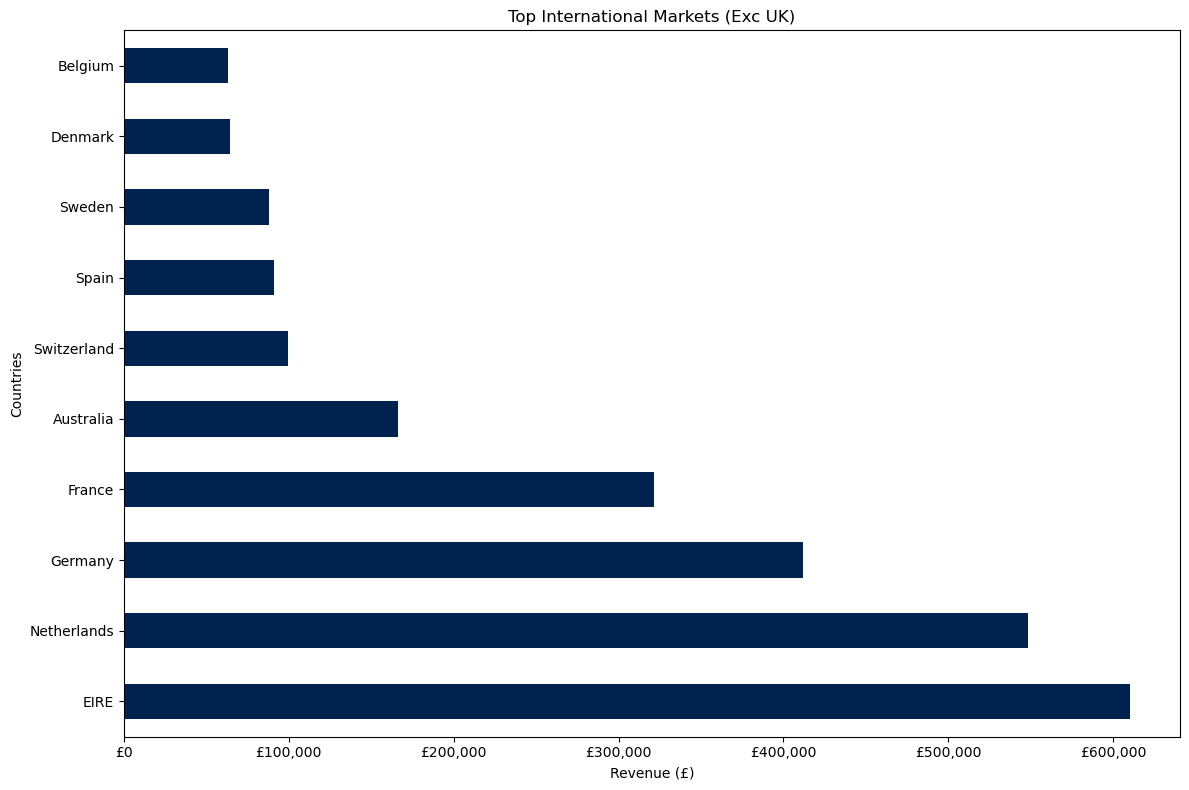

In [32]:
#Visualize
international_revenue.plot(kind='barh', figsize=(12,8), colormap='cividis')
plt.title('Top International Markets (Exc UK)')
plt.xlabel('Revenue (£)')
plt.ylabel('Countries')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show();

In [ ]:
## Top International Markets (Excluding UK) - Key Observations
- **EIRE (Ireland) leads** international markets, likely driven by geographic proximity, shared language and strong trade ties with the UK
- **Netherlands is a close second** — combined with the highest AOV from our earlier analysis, Netherlands is arguably the most valuable international market when considering both revenue volume and order size
- **Germany ranks above France** despite France being geographically closer to the UK — suggests potential untapped opportunity in the French market
- **Australia appearing in the top 10** despite geographic distance suggests strong product appeal or limited local competition for these product types
- The top 4 markets (EIRE, Netherlands, Germany, France) are all European, suggesting the business has a strong European wholesale network but limited penetration in other regions

In [33]:
#Worst Performing Products
worst_products= df.groupby('Description')['Revenue'].sum(). round(2)
worst_products = worst_products[worst_products > 0]
worst_products = worst_products[~worst_products.index.str.contains('POSTAGE', case=False)]
worst_products = worst_products.sort_values(ascending=True).head(10)

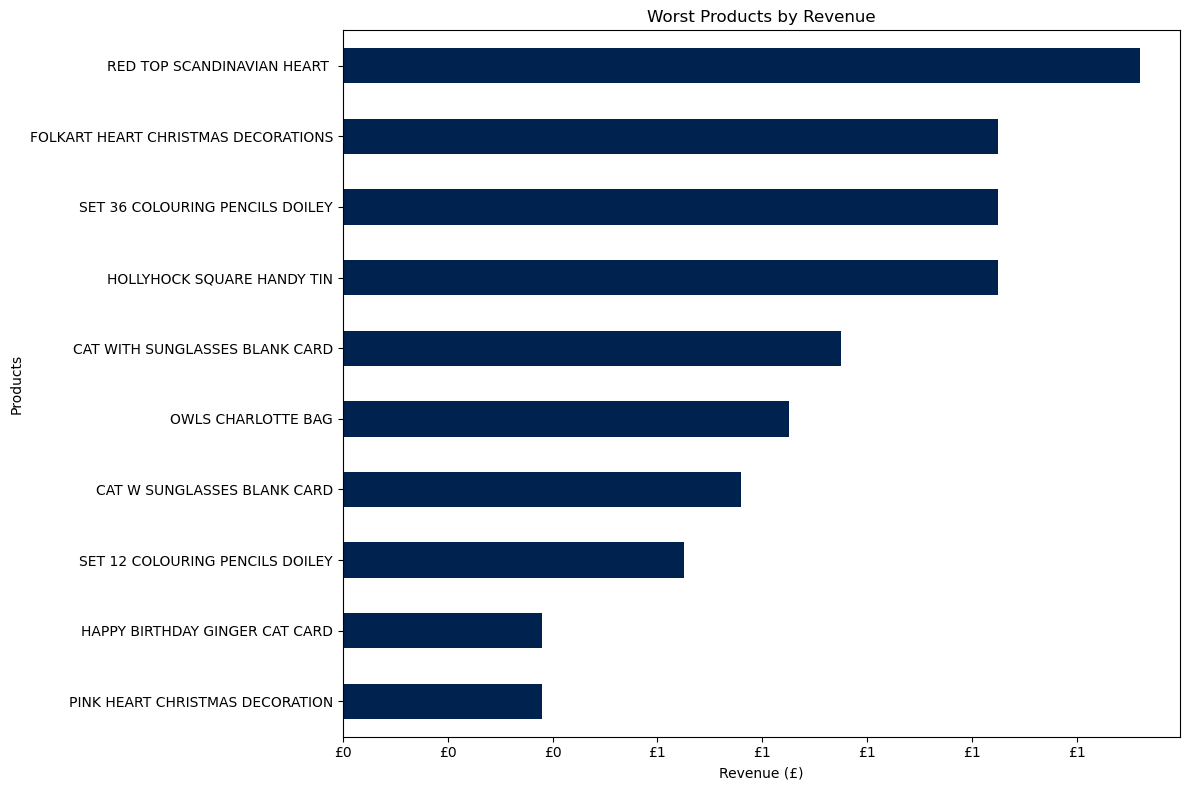

In [34]:
worst_products.plot(kind='barh', figsize=(12,8), colormap='cividis')
plt.title('Worst Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Products')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show();

In [ ]:
## Worst Performing Products - Key Observations
- All bottom 10 products generated less than **£2.00 in total revenue over a 2 year period** — these are effectively dead stock
- **PINK HEART CHRISTMAS DECORATION and HAPPY BIRTHDAY GINGER CAT CARD** are the worst performers at £0.38 each
- **"CAT W SUNGLASSES BLANK CARD" and "CAT WITH SUNGLASSES BLANK CARD"** appear to be the same product with inconsistent data entry — combined revenue is still under £2.00
- Several Christmas/seasonal items appear suggesting poor demand forecasting or discontinued lines still sitting in the catalogue
- **Recommendation:** These products should be reviewed for immediate discontinuation to reduce catalogue complexity and warehousing costs

In [ ]:
# Project Conclusions & Key Findings

## Summary
This analysis of over 1 million retail transactions revealed clear patterns in product performance, seasonal trends, customer markets and operational behaviour. Below are the key findings and recommendations.

## Key Findings

### 1. Market Performance
The UK dominates revenue, accounting for the vast majority of total sales. 
Ireland and Netherlands complete the top 3 markets internationally. 
Netherlands stands out as the highest value international market when combining both revenue and average order value.

### 2. Seasonal Trends
Revenue peaks consistently in October and November across both years, driven by early Christmas and Black Friday purchasing. 
December experiences a sharp decline — dropping -47% in 2010 and -70% in 2011 — suggesting customers are concerned about delivery lead times ahead of Christmas. This worsening trend requires urgent investigation.

### 3. Top Products
The Regency Cakestand 3 Tier leads both revenue (£314,045) and units sold, followed by White Hanging Heart T-Light Holder (£251,603). 
Notably the top 10 products by revenue and quantity are identical, confirming these are the core products driving the business.

### 4. Operational Patterns
Sales are highest Monday to Thursday, peaking on Thursdays, with a sharp decline approaching the weekend. Saturday records near zero activity. 
Orders peak at 12:00pm with a core trading window of 10:00-16:00, consistent with a wholesale B2B customer base ordering during business hours.

### 5. Cancellations
While 19,104 cancellations appear manageable, the quantities tell a different story. 
PAPER CRAFT, LITTLE BIRDIE (80,995 units) and MEDIUM CERAMIC TOP STORAGE JAR (74,494 units) are significant outliers requiring urgent investigation into possible quality or supplier issues.

### 6. Average Order Value
The overall AOV is £382.05. The UK sits below average at £356 despite dominating total revenue, consistent with high volume wholesale ordering. 
Australia, Thailand and Netherlands represent high AOV growth opportunities despite lower total revenue volumes.

## Recommendations
1. Investigate the worsening December revenue decline and consider earlier seasonal marketing campaigns
2. Prioritise Netherlands, Australia and Thailand for targeted sales growth given their high AOV
3. Urgently investigate PAPER CRAFT, LITTLE BIRDIE and MEDIUM CERAMIC TOP STORAGE JAR cancellation volumes
4. Discontinue bottom 10 products generating under £2 in 2 years
5. Optimise staffing and logistics around the core 10:00-16:00 trading window and Tuesday-Thursday peak days